In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import scanpy as sc

In [2]:
with open('../configs/base.yaml', 'r') as file:
    config = yaml.safe_load(file)

config

{'project': {'name': 'scrnaseq_lightgbm', 'random_seed': 42},
 'paths': {'processed_data': 'data/processed', 'artifacts': 'artifacts'},
 'model': {'type': 'lightgbm', 'n_estimators': 100, 'learning_rate': 0.1}}

In [3]:
np.random.seed(config['project']['random_seed'])

In [ ]:
adata = sc.datasets.pbmc3k()
print(adata)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()
print(adata.X.shape)

sc.pp.pca(adata)
X = adata.obsm["X_pca"]
print(X.shape)

sc.pp.neighbors(adata)
sc.tl.leiden(adata)

y = adata.obs["leiden"]
print(y.value_counts())

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
(2700, 1870)
(2700, 50)
leiden
0    559
1    548
2    374
3    348
4    348
5    183
6    154
7    152
8     34
Name: count, dtype: int64


In [ ]:
"""
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=2,
    random_state=config["project"]["random_seed"]
)

print("Full dataset:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
"""

Full dataset:
X shape: (1000, 20)
y shape: (1000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=config["project"]["random_seed"]
)

print("\nAfter train/test split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


After train/test split:
X_train shape: (2160, 50)
X_test shape: (540, 50)
y_train shape: (2160,)
y_test shape: (540,)


In [7]:
model = lgb.LGBMClassifier(
    n_estimators=config["model"]["n_estimators"],
    learning_rate=config["model"]["learning_rate"]
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 2160, number of used features: 50
[LightGBM] [Info] Start training from score -1.611755
[LightGBM] [Info] Start training from score -1.595645
[LightGBM] [Info] Start training from score -1.964131
[LightGBM] [Info] Start training from score -2.011437
[LightGBM] [Info] Start training from score -2.021872
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.849550
[LightGBM] [Info] Start training from score -2.849550
[LightGBM] [Info] Start training from score -4.733425
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [10]:
adata.obs["confidence_lgbm"] = probs.max(axis=1)
adata.obs["predicted_cluster_lgbm"] = model.predict(X).astype(str)

c:\Anaconda\envs\scrna_lightgbm\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
sc.tl.umap(adata)

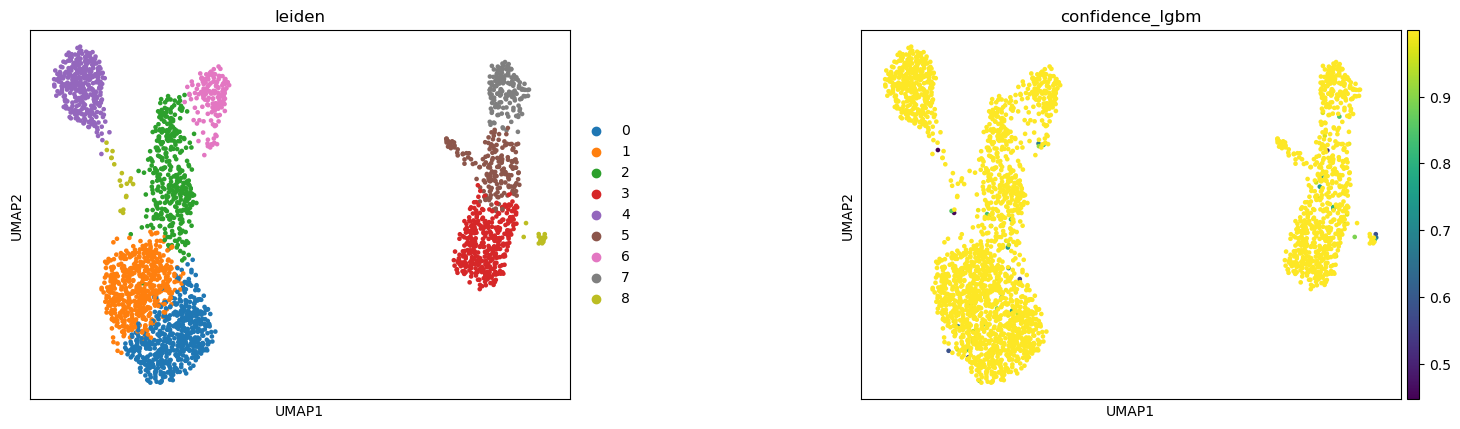

In [12]:
sc.pl.umap(
    adata,
    color=["leiden", "confidence_lgbm"],
    wspace=0.4
)

In [13]:
probs_test = model.predict_proba(X_test)
confidence_test = probs_test.max(axis=1)

import numpy as np
print(np.mean(confidence_test))

0.9816499810418838


c:\Anaconda\envs\scrna_lightgbm\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


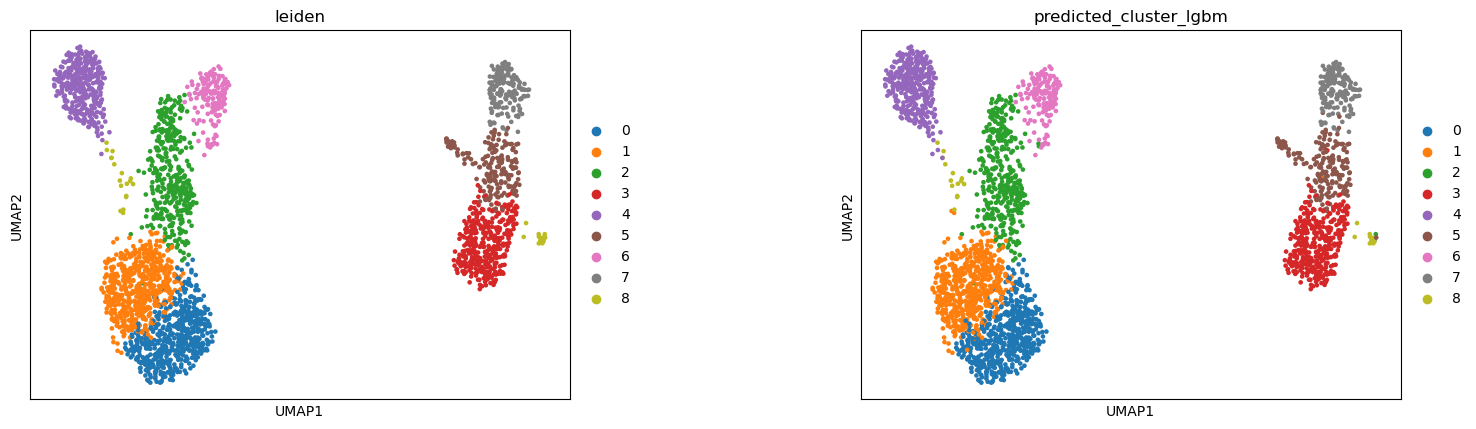

In [14]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_cluster_lgbm"],
    wspace=0.4
)

In [8]:
acc = model.score(X_test, y_test)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.943


c:\Anaconda\envs\scrna_lightgbm\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
probs_test = model.predict_proba(X_test)
probs = model.predict_proba(X)

c:\Anaconda\envs\scrna_lightgbm\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\scrna_lightgbm\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
"""artifacts_dir = "../" + config["paths"]["artifacts"]
os.makedirs(artifacts_dir, exist_ok=True)

model_path = os.path.join(artifacts_dir, "model.txt")
model.booster_.save_model(model_path)

print(f"Model saved to {model_path}")"""

Model saved to ../artifacts\model.txt
